# Cybersickness Early Detection, RR Intervals Data Exploration

This notebook explores the RR intervals data collected from participants during a cybersickness early detection study. The RR intervals represent the time between successive heartbeats, and analyzing this data can provide insights into the physiological responses associated with cybersickness.

## 1. Imports & Setup

In [103]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

DATA_PATH = Path('data/RRintervalsClean.mat')

## 2. Load the .mat File

In [104]:
mat = scipy.io.loadmat(DATA_PATH)

print('MATLAB file keys:', [k for k in mat.keys() if not k.startswith('_')])

raw = mat['RRintervalsClean']
print(f'\nCell array shape: {raw.shape}  â  {raw.shape[0]} subjects Ã {raw.shape[1]} columns')
print(f'Element dtype: {raw.dtype}')

print('\nColumn types:')
for i in range(raw.shape[1]):
    col_data = raw[:, i]
    if isinstance(col_data[0], np.ndarray):
        print(f'Column {i}: MATLAB struct array (non-numeric)')
    else:
        print(f'Column {i}: Numeric array (uint16)')

print('\nExample numeric column (Column 0) stats:')
col0_lengths = [len(row[0]) for row in raw[:, 0]]
print(f'  Number of RR intervals per subject: min={min(col0_lengths)}, max={max(col0_lengths)}, mean={np.mean(col0_lengths):.1f}, std={np.std(col0_lengths):.1f}')



MATLAB file keys: ['RRintervalsClean']

Cell array shape: (36, 10)  â  36 subjects Ã 10 columns
Element dtype: object

Column types:
Column 0: MATLAB struct array (non-numeric)
Column 1: MATLAB struct array (non-numeric)
Column 2: MATLAB struct array (non-numeric)
Column 3: MATLAB struct array (non-numeric)
Column 4: MATLAB struct array (non-numeric)
Column 5: MATLAB struct array (non-numeric)
Column 6: MATLAB struct array (non-numeric)
Column 7: MATLAB struct array (non-numeric)
Column 8: MATLAB struct array (non-numeric)
Column 9: MATLAB struct array (non-numeric)

Example numeric column (Column 0) stats:
  Number of RR intervals per subject: min=1, max=1, mean=1.0, std=0.0


## 3. Data Structure Overview

In [122]:
def extract_rr(cell):
    arr = np.array(cell)
    if arr.dtype.names:
        return None
    flat = arr.flatten().astype(np.float64)
    return flat if flat.size > 0 else None

def col_is_numeric(raw, j):
    """A column is numeric if at least one subject has a non-None RR array in it."""
    return any(extract_rr(raw[i, j]) is not None for i in range(raw.shape[0]))

numeric_cols = [j for j in range(raw.shape[1]) if col_is_numeric(raw, j)]
other_cols   = [j for j in range(raw.shape[1]) if j not in numeric_cols]

print(f'Numeric (RR) columns : {numeric_cols}')
print(f'Non-numeric columns  : {other_cols}  (IDs sujets encodés MATLAB)')

# Labels des conditions, source : email équipe + article Frontiers in VR 2024
# (doi: 10.3389/frvir.2024.1358981), 36 sujets étudiants sport
# Protocole réel  : Baseline → Cohérence cardiaque (respiration 0.1 Hz)
# Protocole VR    : Baseline → Immersion VR → Cohérence cardiaque VR
cond_labels = {
    0: 'Baseline (réel)',                        # MATLAB col 1, 5 min repos
    1: 'Cohérence cardiaque (réel)',             # MATLAB col 2, respiration 0.1 Hz
    2: 'Inconnu (longue durée ~20 min)',         # MATLAB col 3, non décrit dans l'article
    3: 'Inconnu',                                # MATLAB col 4, non décrit dans l'article
    5: 'Baseline (VR)',                          # MATLAB col 6, 5 min repos avant VR
    6: 'Immersion VR',                           # MATLAB col 7, environnement VR relaxant
    7: 'Cohérence cardiaque (VR)',               # MATLAB col 8, respiration 0.1 Hz en VR
    8: 'Inconnu',                                # MATLAB col 9, non décrit dans l'article
}

print('\nColumn, Condition mapping:')
for col in numeric_cols:
    print(f'  Python col {col}  (MATLAB col {col+1}),  {cond_labels[col]}')

Numeric (RR) columns : [0, 1, 2, 3, 5, 6, 7, 8]
Non-numeric columns  : [4, 9]  (IDs sujets encodés MATLAB)

Column, Condition mapping:
  Python col 0  (MATLAB col 1),  Baseline (réel)
  Python col 1  (MATLAB col 2),  Cohérence cardiaque (réel)
  Python col 2  (MATLAB col 3),  Inconnu (longue durée ~20 min)
  Python col 3  (MATLAB col 4),  Inconnu
  Python col 5  (MATLAB col 6),  Baseline (VR)
  Python col 6  (MATLAB col 7),  Immersion VR
  Python col 7  (MATLAB col 8),  Cohérence cardiaque (VR)
  Python col 8  (MATLAB col 9),  Inconnu


## 4. Per-Subject, Per-Condition Summary Table

In [106]:
N_SUBJECTS = raw.shape[0]
records = []

for subj in range(N_SUBJECTS):
    for col in numeric_cols:
        rr = extract_rr(raw[subj, col])
        if rr is None or rr.size == 0:
            continue
        hr = 60_000.0 / rr          
        diff_rr = np.diff(rr)        
        records.append({
            'subject'   : subj + 1,
            'condition' : cond_labels[col],
            'col_idx'   : col,
            'n_beats'   : rr.size,
            'duration_s': rr.sum() / 1000,         
            'rr_mean_ms': rr.mean(),
            'rr_std_ms' : rr.std(),
            'rr_min_ms' : rr.min(),
            'rr_max_ms' : rr.max(),
            'hr_mean_bpm': hr.mean(),
            'sdnn_ms'   : rr.std(ddof=1),
            'rmssd_ms'  : np.sqrt(np.mean(diff_rr**2)), 
            'pnn50_pct' : 100 * np.mean(np.abs(diff_rr) > 50),
        })

df = pd.DataFrame(records)
print(f'Total records: {len(df)}  ({N_SUBJECTS} subjects Ã {len(numeric_cols)} conditions)')
df.head(10).round(2)

Total records: 276  (36 subjects Ã 8 conditions)


,subject,condition,col_idx,n_beats,duration_s,rr_mean_ms,rr_std_ms,rr_min_ms,rr_max_ms,hr_mean_bpm,sdnn_ms,rmssd_ms,pnn50_pct
0,1,Baseline (rÃ©el),0,397,303.52,764.53,56.90,620.0,897.0,78.93,56.97,34.48,13.89
1,1,CohÃ©rence cardiaque (rÃ©el),1,396,299.44,756.16,77.21,603.0,966.0,80.17,77.31,36.49,15.19
2,1,Inconnu (longue durÃ©e ~20 min),2,1580,1203.43,761.66,65.28,587.0,983.0,79.36,65.30,36.95,16.47
3,1,Inconnu,3,402,300.38,747.23,72.63,612.0,1011.0,81.03,72.72,36.23,13.97
4,1,Baseline (VR),5,487,306.77,629.92,38.53,530.0,756.0,95.61,38.57,21.32,3.50
5,1,Immersion VR,6,463,309.13,667.67,32.33,568.0,759.0,90.08,32.37,19.50,2.16
6,1,CohÃ©rence cardiaque (VR),7,440,302.59,687.70,69.44,555.0,859.0,88.14,69.52,31.67,7.06
7,2,Baseline (rÃ©el),0,398,311.89,783.64,85.23,532.0,984.0,77.53,85.34,134.24,61.46
8,2,CohÃ©rence cardiaque (rÃ©el),1,408,303.40,743.62,40.49,611.0,867.0,80.93,40.54,36.87,14.74
9,2,Inconnu (longue durÃ©e ~20 min),2,1497,1228.72,820.79,70.68,357.0,1201.0,73.71,70.70,64.71,28.81


In [107]:
def show_by_subject(df, condition=None, metric='rr_mean_ms'):
    """
    Affiche un tableau avec les sujets en colonnes et les conditions en lignes.

    Parameters
    ----------
    df        : DataFrame construit dans la cellule prÃ©cÃ©dente
    condition : str ou None â filtre sur une condition (ex: 'Cond 1').
                Si None, affiche toutes les conditions.
    metric    : str â mÃ©trique Ã  afficher.
                Valeurs possibles :
                'n_beats', 'duration_s', 'rr_mean_ms', 'rr_std_ms',
                'hr_mean_bpm', 'sdnn_ms', 'rmssd_ms', 'pnn50_pct'
    """
    data = df if condition is None else df[df['condition'] == condition]

    pivot = (
        data.pivot(index='condition', columns='subject', values=metric)
            .round(2)
    )
    pivot.columns = [f'S{c}' for c in pivot.columns]  # S1, S2, â¦
    pivot.index.name = None
    pivot.columns.name = metric

    return pivot

# --- Exemples ---

# Toutes conditions, RR moyen
print("=== Mean RR (ms) â toutes conditions ===")
def show_by_subject(df, condition=None, metric='rr_mean_ms'):
    data = df if condition is None else df[df['condition'] == condition]
    data = data.copy()

    dup_idx = data.groupby(['condition', 'subject']).cumcount()
    data['condition'] = np.where(
        dup_idx == 0,
        data['condition'],
        data['condition'] + ' #' + (dup_idx + 1).astype(str)
    )

    pivot = (
        data.pivot(index='condition', columns='subject', values=metric)
            .round(2)
    )
    pivot.columns = [f'S{c}' for c in pivot.columns]
    pivot.index.name = None
    pivot.columns.name = metric

    return pivot

# --- Exemples ---

# Toutes conditions, RR moyen
display(show_by_subject(df, condition=None, metric='rr_mean_ms'))

=== Mean RR (ms) â toutes conditions ===


rr_mean_ms,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,...,S27,S28,S29,S30,S31,S32,S33,S34,S35,S36
Baseline (VR),629.92,695.56,742.72,796.11,944.56,887.59,1025.17,791.98,989.75,849.00,...,1027.59,829.39,670.56,852.76,814.30,892.93,563.76,785.90,883.22,914.07
Baseline (rÃ©el),764.53,783.64,826.41,967.67,1114.56,743.39,1126.24,965.76,1012.20,940.42,...,958.91,925.97,724.69,717.48,832.49,763.36,609.78,696.97,680.61,995.01
CohÃ©rence cardiaque (VR),687.70,745.55,738.71,731.80,1052.74,863.80,885.14,985.03,1017.65,832.35,...,1121.23,857.36,704.89,799.88,945.84,910.89,597.79,864.86,834.02,933.57
CohÃ©rence cardiaque (rÃ©el),756.16,743.62,740.08,882.30,1101.34,833.85,1003.30,1090.38,911.22,914.20,...,1052.33,940.57,797.42,716.43,897.17,826.89,609.66,804.81,684.23,942.18
Immersion VR,667.67,718.92,804.13,809.69,1021.23,873.51,1043.46,940.49,1149.14,877.93,...,1099.36,775.01,697.08,903.52,848.70,914.41,621.33,832.69,877.23,958.28
Inconnu,747.23,839.99,1020.97,924.81,1131.51,851.46,1080.77,1089.43,1033.44,951.76,...,1029.27,905.34,739.36,754.76,867.30,820.26,684.85,756.92,702.29,973.23
Inconnu #2,NaN,744.57,753.49,NaN,973.41,849.92,973.11,884.28,969.15,NaN,...,1005.01,910.78,662.33,922.84,839.26,888.70,649.43,804.03,846.45,917.18
Inconnu (longue durÃ©e ~20 min),761.66,820.79,1019.24,983.90,1097.34,858.91,1057.50,1098.53,1075.24,972.85,...,1083.28,860.89,738.76,742.61,828.57,815.37,650.47,799.74,707.46,969.10


## 5. Dataset Summary

In [108]:
summary_cols = ['n_beats', 'duration_s', 'rr_mean_ms', 'rr_std_ms', 'hr_mean_bpm',
                'sdnn_ms', 'rmssd_ms', 'pnn50_pct']

print('=== Overall dataset statistics ===')
display(df[summary_cols].describe().round(2))

=== Overall dataset statistics ===


,n_beats,duration_s,rr_mean_ms,rr_std_ms,hr_mean_bpm,sdnn_ms,rmssd_ms,pnn50_pct
count,276.00,276.00,276.00,276.00,276.00,276.00,276.00,276.00
mean,507.79,435.18,869.47,96.72,71.66,96.85,73.78,34.23
std,356.67,306.22,135.22,41.29,11.09,41.36,41.40,20.72
min,251.00,272.25,563.76,30.17,48.90,30.20,11.94,0.19
25%,331.75,301.07,764.16,65.76,63.75,65.87,43.29,15.10
50%,377.00,309.31,858.62,89.83,71.16,89.94,67.27,35.38
75%,449.00,340.30,953.39,116.82,79.56,117.00,96.21,51.07
max,1928.00,1392.01,1260.33,248.08,106.73,248.44,258.25,83.88


## 6. Per-Condition Summary

In [109]:
cond_summary = (
    df.groupby('condition')[summary_cols]
      .agg(['mean', 'std'])
      .round(2)
)
cond_summary.columns = ['_'.join(c) for c in cond_summary.columns]

print('=== Per-condition mean Â± std ===')
display(cond_summary)

=== Per-condition mean Â± std ===


,n_beats_mean,n_beats_std,duration_s_mean,duration_s_std,rr_mean_ms_mean,rr_mean_ms_std,rr_std_ms_mean,rr_std_ms_std,hr_mean_bpm_mean,hr_mean_bpm_std,sdnn_ms_mean,sdnn_ms_std,rmssd_ms_mean,rmssd_ms_std,pnn50_pct_mean,pnn50_pct_std
condition,,,,,,,,,,,,,,,,
Baseline (VR),394.81,74.64,321.54,38.16,832.98,131.21,71.88,29.93,74.36,11.69,71.98,29.97,54.74,32.79,27.91,20.55
Baseline (rÃ©el),383.89,67.58,321.79,24.98,860.97,146.74,77.12,25.12,72.29,12.27,77.23,25.17,67.72,36.88,33.20,23.82
CohÃ©rence cardiaque (VR),361.83,55.56,304.11,9.53,858.94,128.36,130.11,41.40,73.02,10.43,130.30,41.47,89.62,41.45,38.02,17.64
CohÃ©rence cardiaque (rÃ©el),368.11,72.06,310.43,22.05,865.80,131.93,134.94,47.41,72.70,11.13,135.14,47.49,97.25,51.42,40.11,17.51
Immersion VR,366.22,65.81,314.00,32.24,877.24,142.12,78.28,34.52,70.67,11.00,78.39,34.58,64.48,42.23,30.39,20.45
Inconnu,378.08,64.78,326.34,30.11,880.86,126.45,92.91,31.54,70.35,10.13,93.04,31.59,70.73,36.10,34.36,21.04
Inconnu (longue durÃ©e ~20 min),1388.08,228.67,1220.61,37.61,901.93,144.71,94.37,31.30,69.07,11.39,94.41,31.32,73.97,36.69,35.55,22.16


## 7. Recording Length per Condition

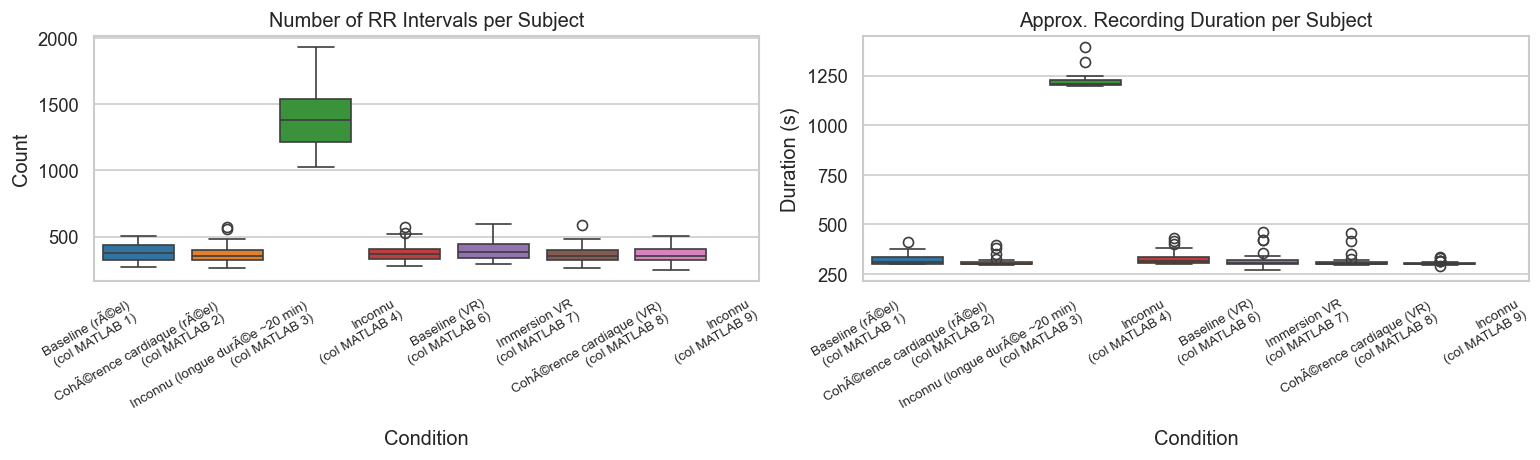

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Ordre et labels pour l'axe x
cond_order = [cond_labels[c] for c in numeric_cols]
tick_labels = [f'{cond_labels[c]}\n(col MATLAB {c+1})' for c in numeric_cols]

# n_beats
sns.boxplot(data=df, x='condition', y='n_beats', order=cond_order,
            ax=axes[0], hue='condition', legend=False, palette='tab10')
axes[0].set_title('Number of RR Intervals per Subject')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(len(cond_order)))
axes[0].set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=8)

# approx duration
sns.boxplot(data=df, x='condition', y='duration_s', order=cond_order,
            ax=axes[1], hue='condition', legend=False, palette='tab10')
axes[1].set_title('Approx. Recording Duration per Subject')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Duration (s)')
axes[1].set_xticks(range(len(cond_order)))
axes[1].set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

## 8. RR Interval Distributions by Condition

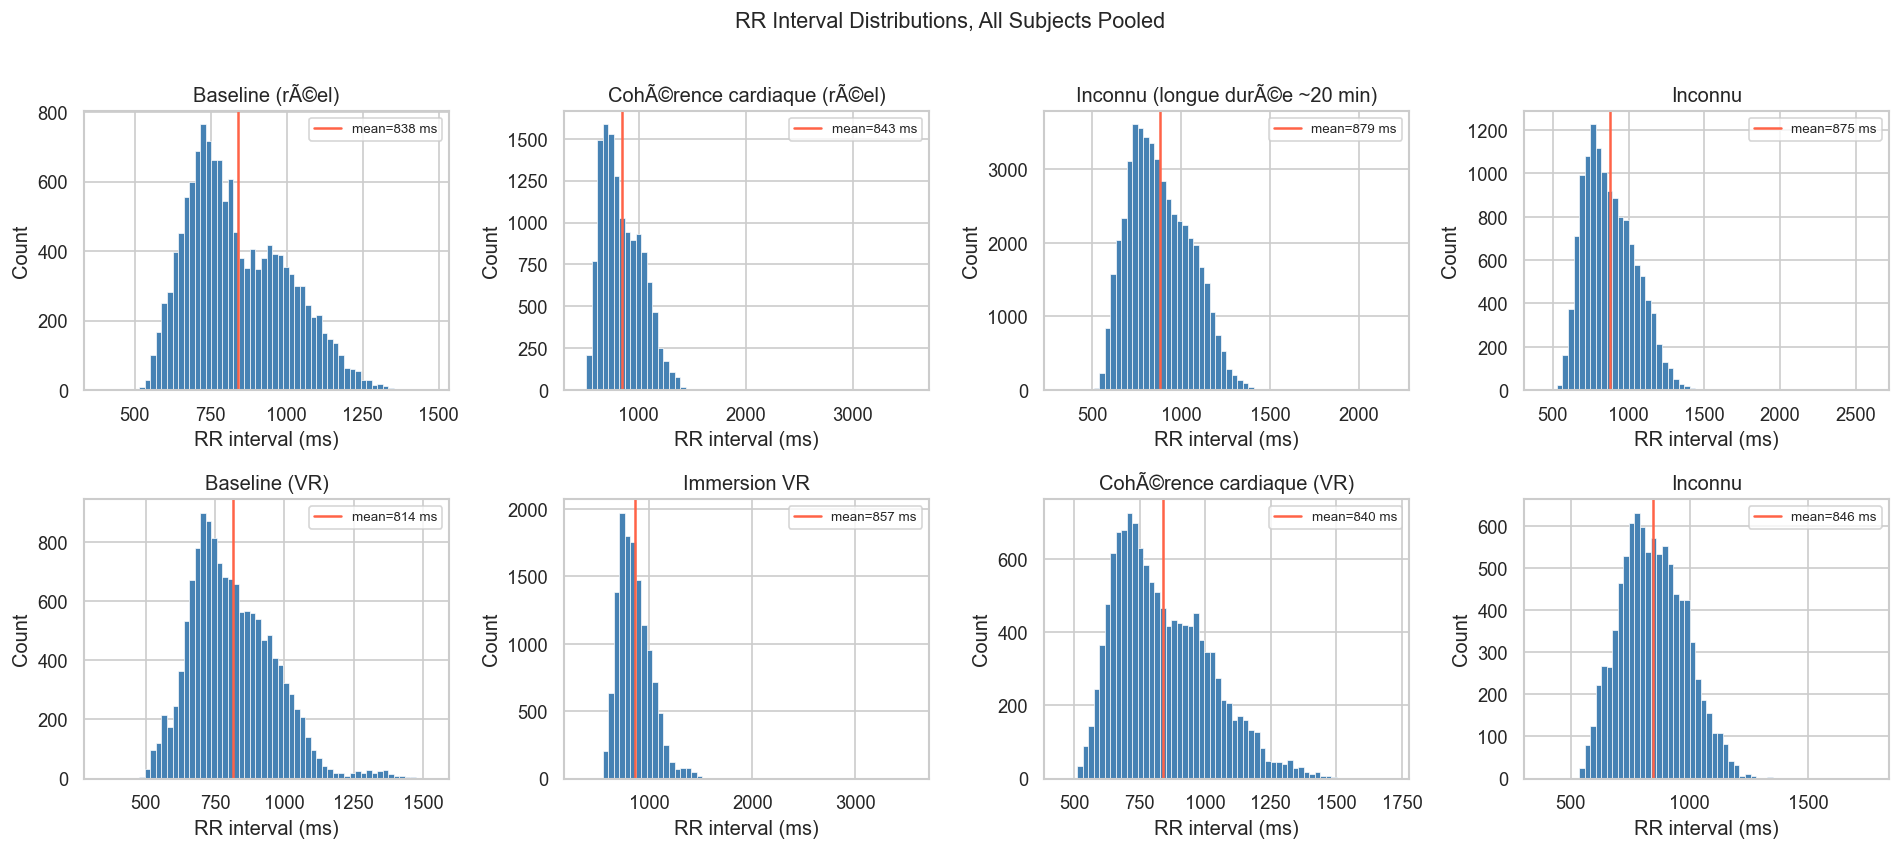

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    all_rr = np.concatenate([extract_rr(raw[s, col]) for s in range(N_SUBJECTS)
                             if extract_rr(raw[s, col]) is not None])
    ax.hist(all_rr, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.axvline(all_rr.mean(), color='tomato', lw=1.5, label=f'mean={all_rr.mean():.0f} ms')
    ax.set_title(cond_labels[col])
    ax.set_xlabel('RR interval (ms)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('RR Interval Distributions, All Subjects', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 9. Heart Rate (Mean BPM) per Condition

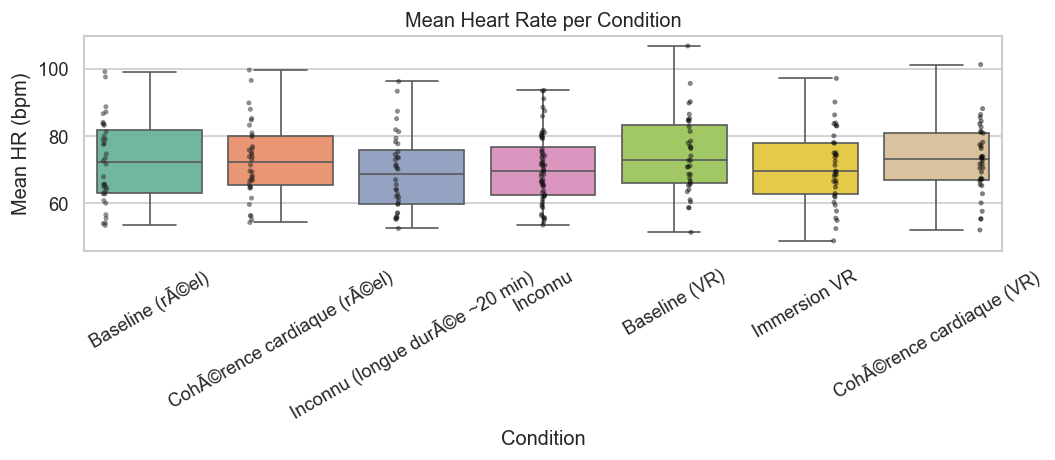

In [112]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df, x='condition', y='hr_mean_bpm', palette='Set2', ax=ax, hue='condition', legend=False)
sns.stripplot(data=df, x='condition', y='hr_mean_bpm', color='black', size=3, alpha=0.5, jitter=True, ax=ax, 
              hue='condition', dodge=True, legend=False, palette='dark:black')
ax.set_title('Mean Heart Rate per Condition')
ax.set_xlabel('Condition')
ax.set_ylabel('Mean HR (bpm)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 10. HRV Metrics per Condition (SDNN, RMSSD, pNN50)

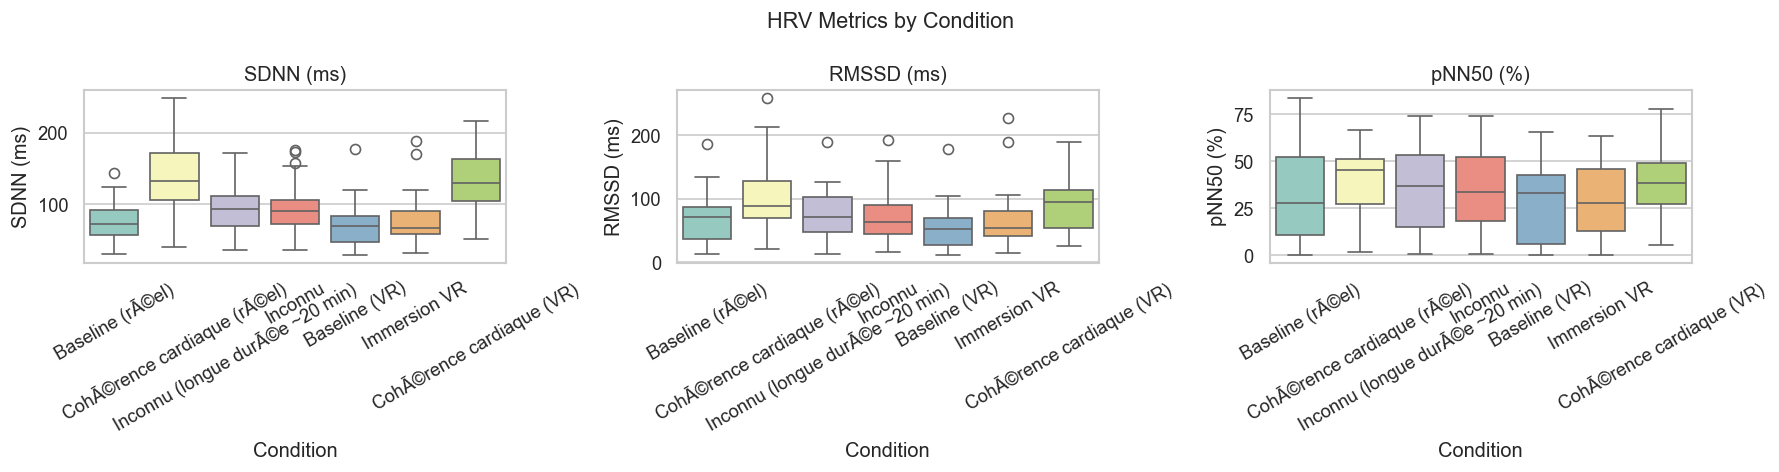

In [113]:
hrv_metrics = ['sdnn_ms', 'rmssd_ms', 'pnn50_pct']
hrv_titles  = ['SDNN (ms)', 'RMSSD (ms)', 'pNN50 (%)']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, title in zip(axes, hrv_metrics, hrv_titles):
    sns.boxplot(data=df, x='condition', y=metric, palette='Set3', ax=ax, hue='condition', legend=False)
    ax.set_title(title)
    ax.set_xlabel('Condition')
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('HRV Metrics by Condition', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Subject-Level Mean RR Heatmap

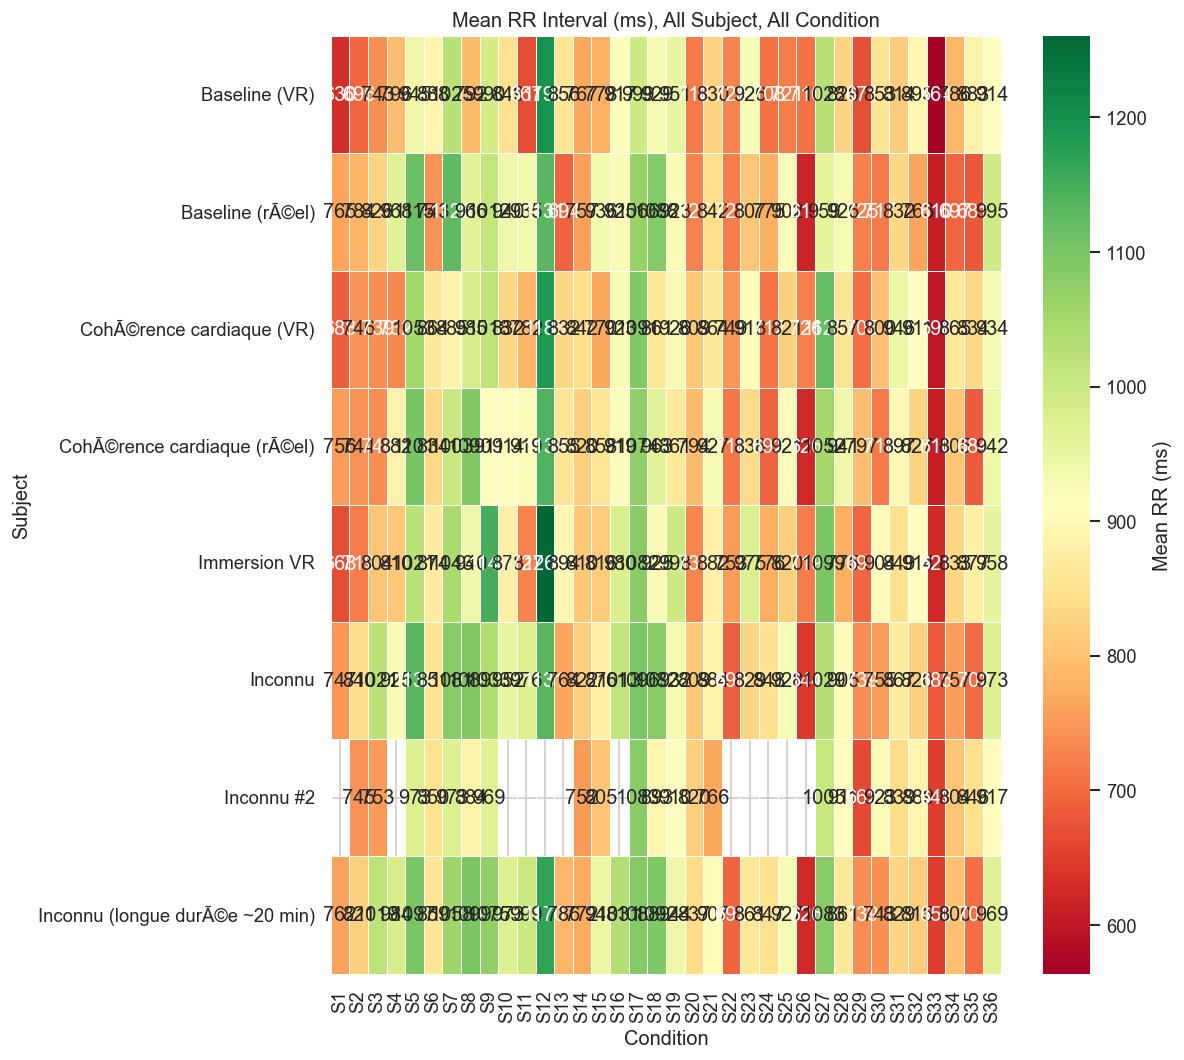

In [120]:
pivot = show_by_subject(df, condition=None, metric='rr_mean_ms')

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn',
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Mean RR (ms)'}, ax=ax)
ax.set_title('Mean RR Interval (ms), All Subject, All Condition')
ax.set_xlabel('Condition')
ax.set_ylabel('Subject')
plt.tight_layout()
plt.show()

## 12. Example RR Time Series, 1 Subject, All Conditions

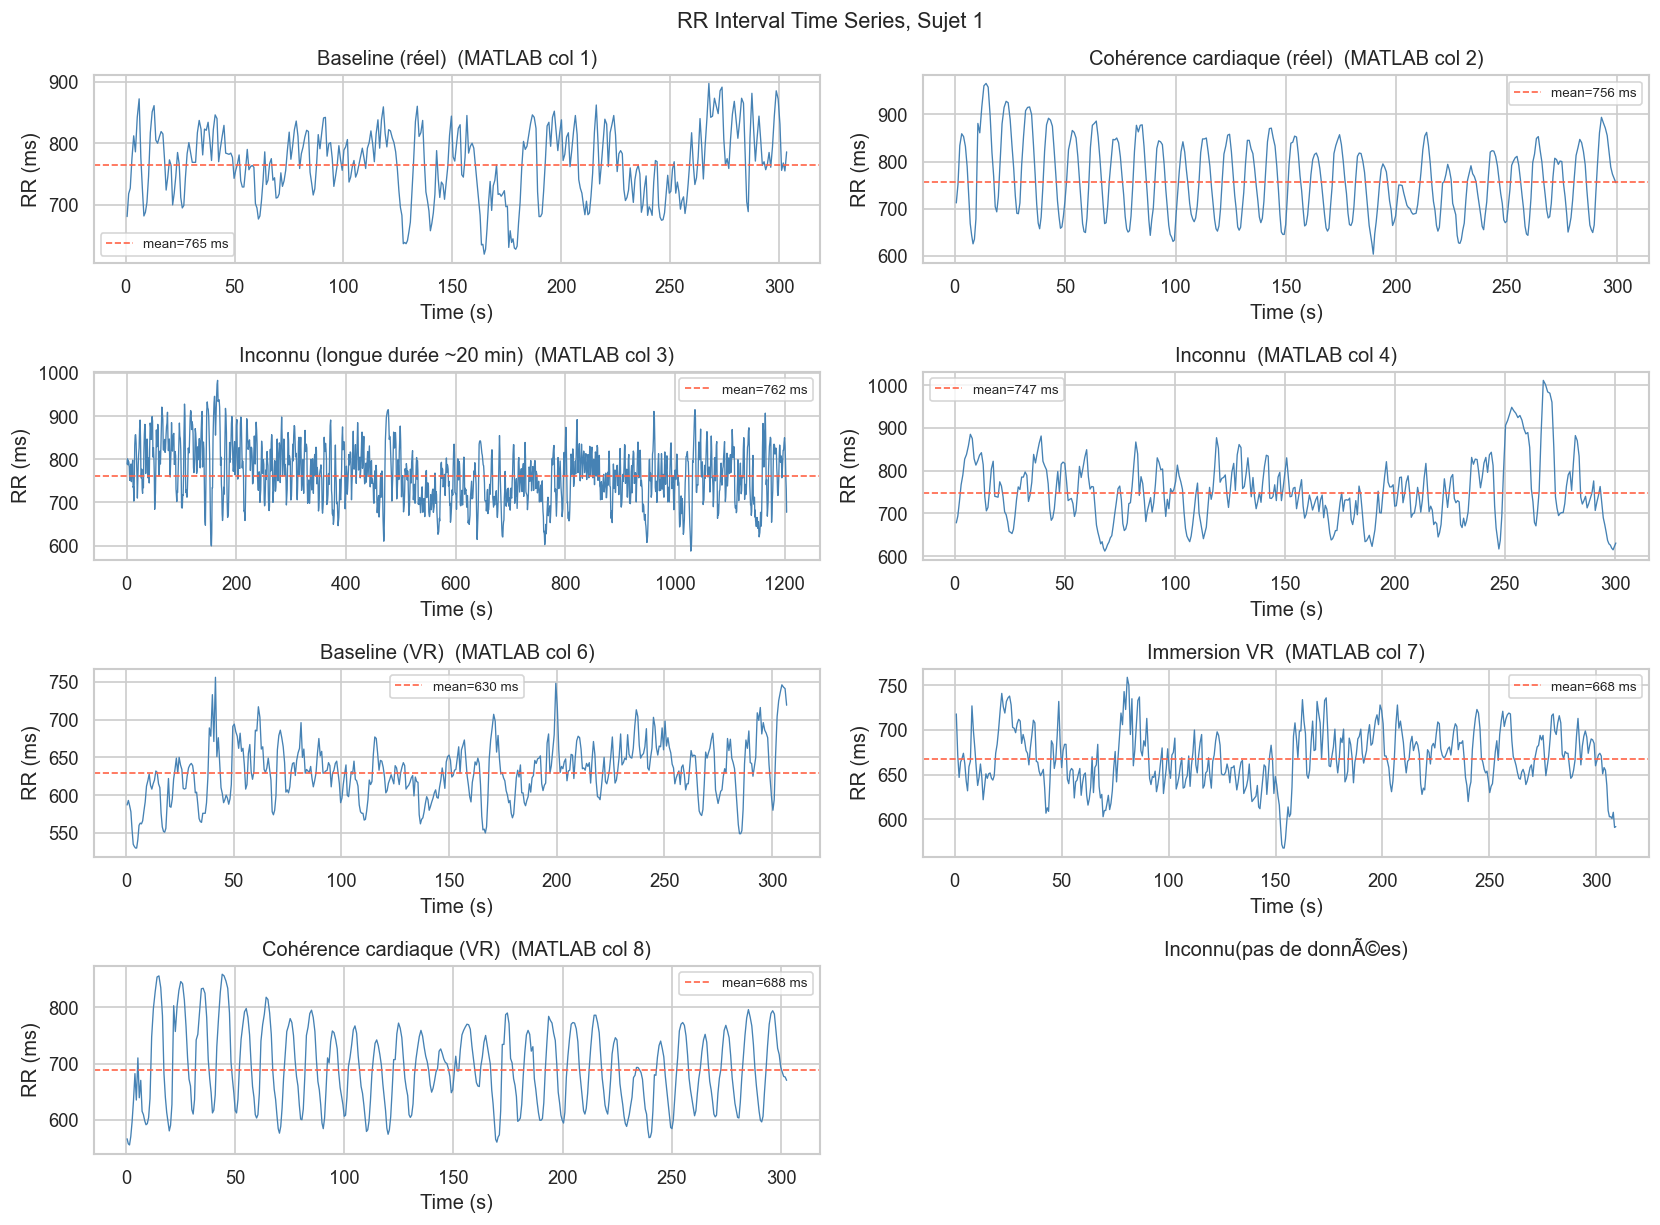

In [149]:
SUBJECT = 1

subj_idx = SUBJECT - 1

n_cond = len(numeric_cols)
ncols_plot = 2
nrows_plot = (n_cond + 1) // ncols_plot

fig, axes = plt.subplots(nrows_plot, ncols_plot, figsize=(14, nrows_plot * 2.6), sharex=False)
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    rr = extract_rr(raw[subj_idx, col])
    if rr is None:
        ax.set_title(f"{cond_labels[col]}(pas de donnÃ©es)")
        ax.axis("off")
        continue
    cumtime = np.cumsum(rr) / 1000
    ax.plot(cumtime, rr, lw=0.8, color="steelblue")
    ax.axhline(rr.mean(), color="tomato", lw=1, linestyle="--",
               label=f"mean={rr.mean():.0f} ms")
    ax.set_title(f"{cond_labels[col]}  (MATLAB col {col+1})")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("RR (ms)")
    ax.legend(fontsize=8)

for ax in axes[n_cond:]:
    ax.set_visible(False)

plt.suptitle(f"RR Interval Time Series, Sujet {SUBJECT}", fontsize=13)
plt.tight_layout()
plt.show()


## 13. RR Time Series, All Subjects, one Condition

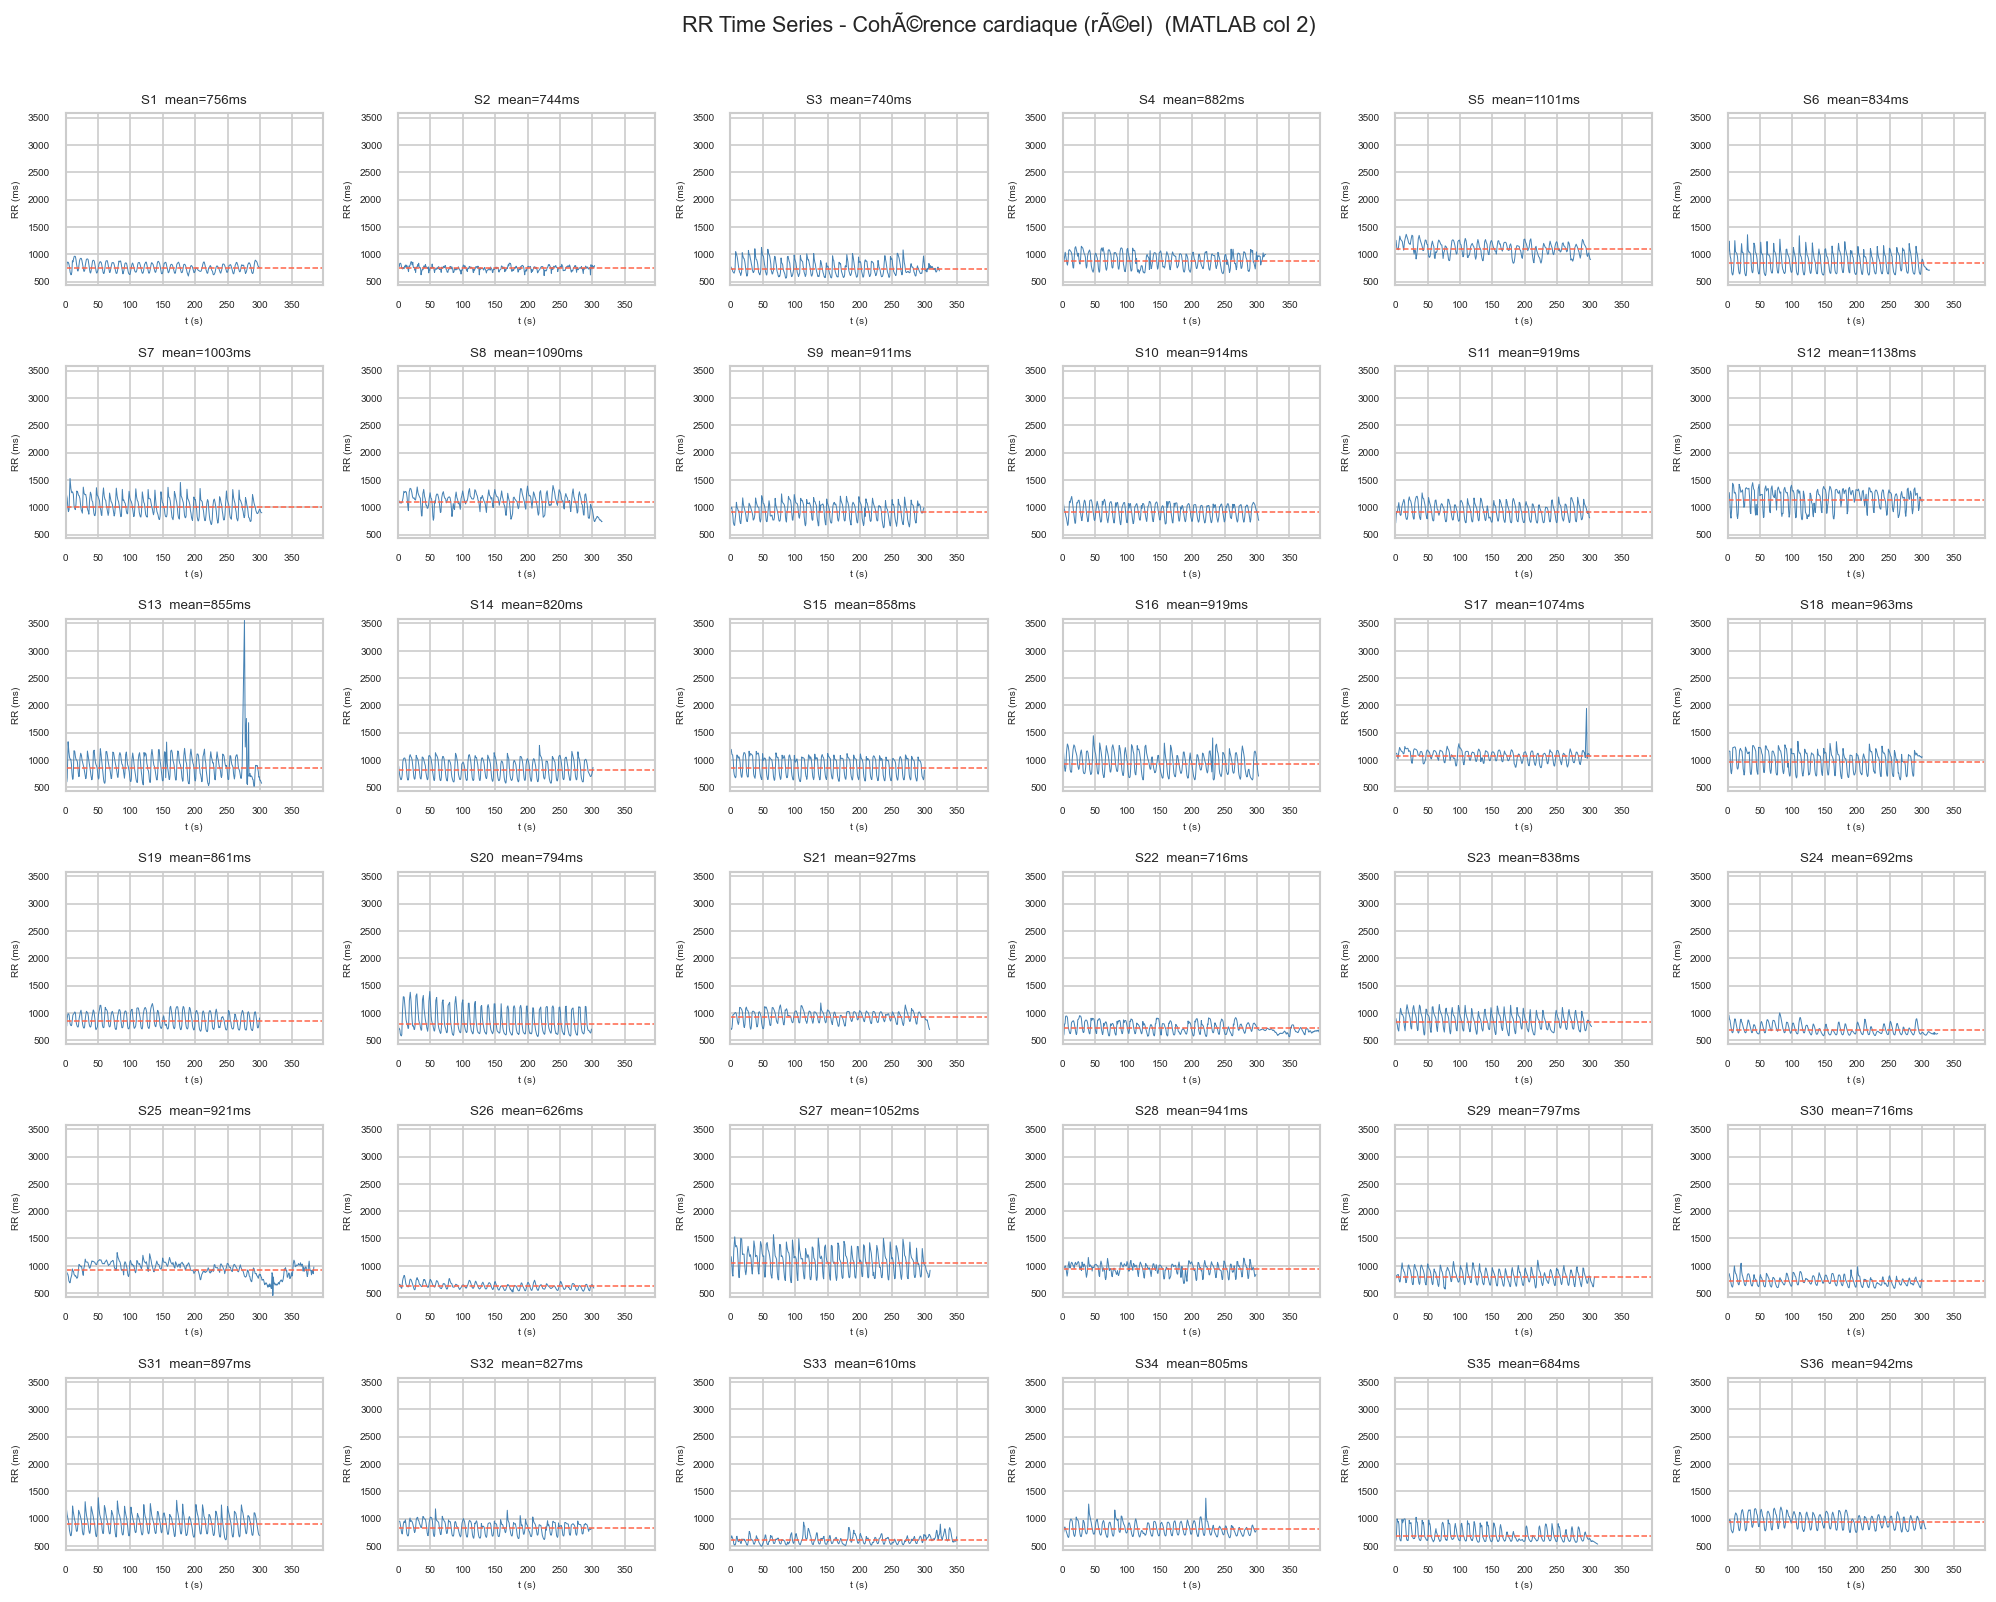

In [116]:
def plot_all_subjects(condition_col, ncols=6):
    """
    Affiche les series RR de tous les sujets pour une condition donnee.
    Tous les axes partagent la meme echelle Y pour permettre la comparaison.
    condition_col : indice Python (0-based) de la colonne a afficher.
    ncols         : nombre de colonnes dans la grille (defaut 6).
    """
    n_subj = raw.shape[0]
    nrows  = -(-n_subj // ncols)
    label  = cond_labels.get(condition_col, f"col {condition_col}")

    # Calcul des limites globales sur tous les sujets pour cette condition
    all_rr = [extract_rr(raw[i, condition_col]) for i in range(n_subj)]
    valid  = [r for r in all_rr if r is not None]
    y_min  = min(r.min() for r in valid) - 20
    y_max  = max(r.max() for r in valid) + 20
    x_max  = max(np.cumsum(r)[-1] / 1000 for r in valid)

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 2.8, nrows * 2.2),
                             sharex=False, sharey=False)
    axes = axes.flatten()

    for subj_idx, ax in enumerate(axes[:n_subj]):
        rr = all_rr[subj_idx]
        if rr is None:
            ax.set_title(f"S{subj_idx+1} - N/A", fontsize=8)
            ax.axis("off")
            continue
        cumtime = np.cumsum(rr) / 1000
        ax.plot(cumtime, rr, lw=0.6, color="steelblue")
        ax.axhline(rr.mean(), color="tomato", lw=0.9, linestyle="--")
        ax.set_title(f"S{subj_idx+1}  mean={rr.mean():.0f}ms", fontsize=8)
        ax.set_xlim(0, x_max)
        ax.set_ylim(y_min, y_max)
        ax.tick_params(labelsize=6)
        ax.set_xlabel("t (s)", fontsize=6)
        ax.set_ylabel("RR (ms)", fontsize=6)

    for ax in axes[n_subj:]:
        ax.set_visible(False)

    plt.suptitle(
        f"RR Time Series - {label}  (MATLAB col {condition_col+1})",
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.show()


# ---- Choisir la condition a afficher ----
CONDITION_COL = 1   # 0=Baseline reel, 1=Coherence cardiaque reel,
#                     5=Baseline VR, 6=Immersion VR, 7=Coherence cardiaque VR

plot_all_subjects(CONDITION_COL)


## 14. Poincaré Plot per Condition

Plot of RR(n) vs RR(n+1). **SD1** = short-term parasympathetic variability; **SD2** = long-term overall HRV. A narrower cloud (lower SD1/SD2) indicates sympathetic dominance  a key cybersickness marker.

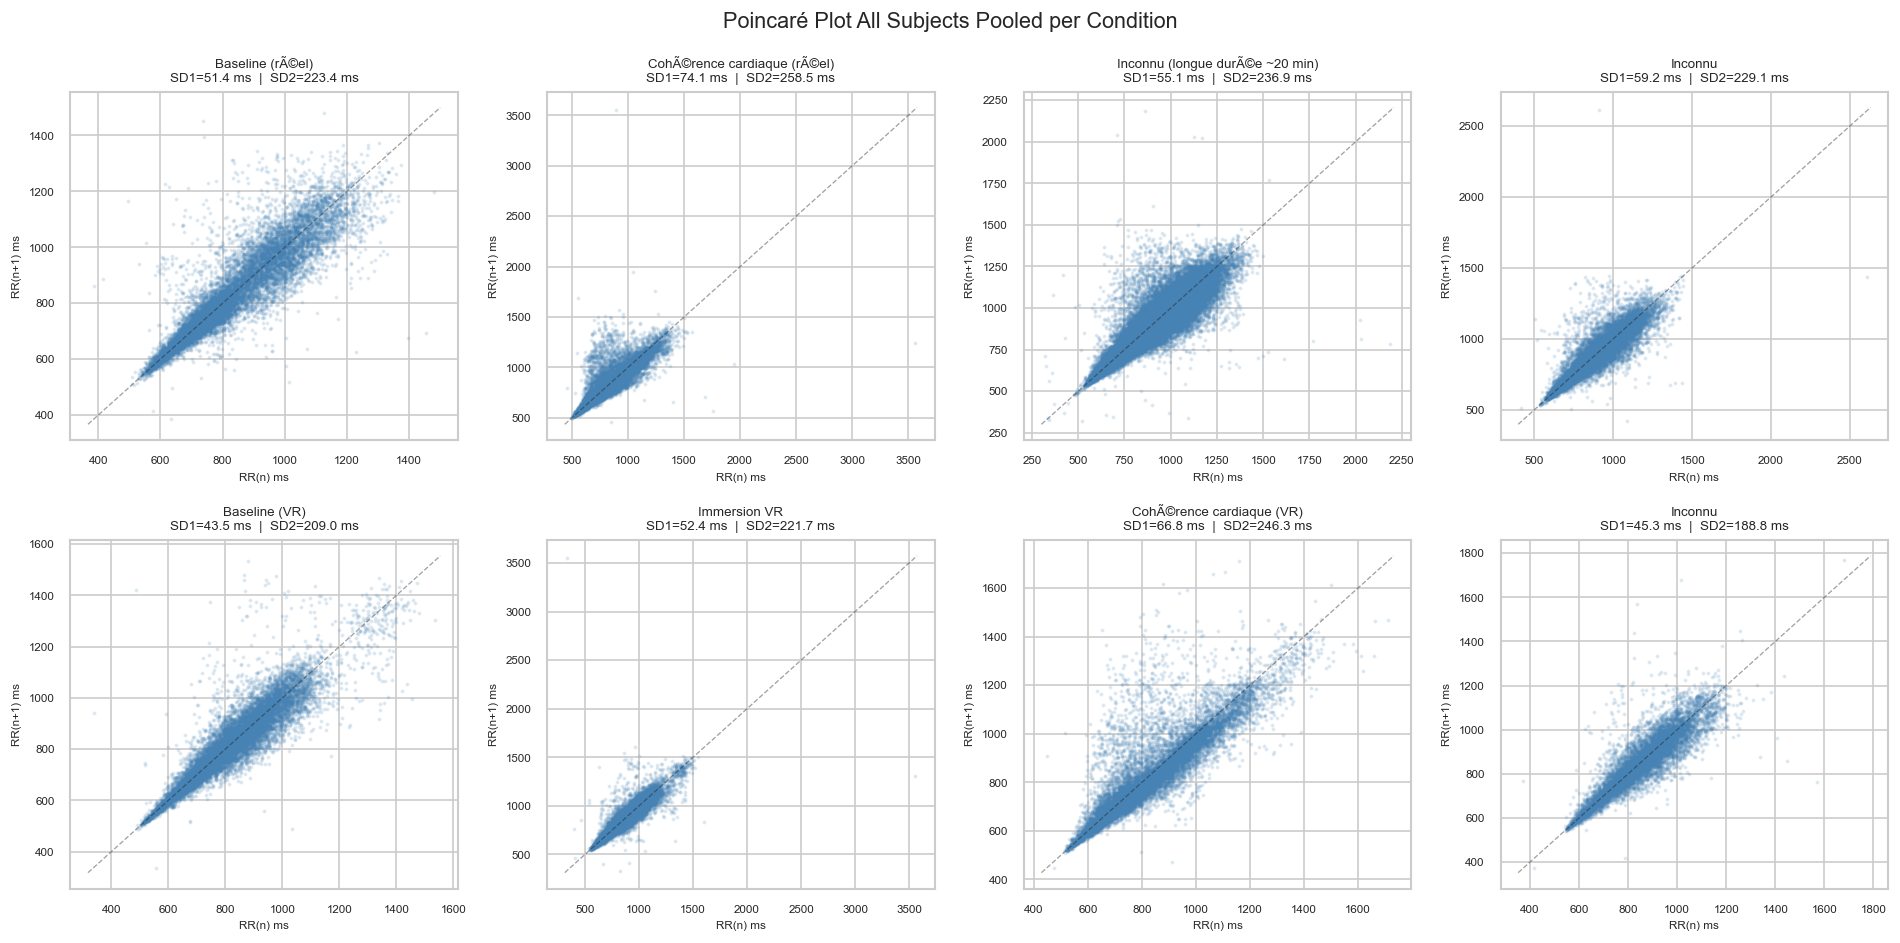

In [117]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    xs, ys = [], []
    for s in range(N_SUBJECTS):
        rr = extract_rr(raw[s, col])
        if rr is not None and rr.size > 2:
            xs.extend(rr[:-1].tolist())
            ys.extend(rr[1:].tolist())
    x, y = np.array(xs), np.array(ys)
    ax.scatter(x, y, alpha=0.12, s=2, color="steelblue")
    lo = min(x.min(), y.min()) - 20
    hi = max(x.max(), y.max()) + 20
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.4)
    sd1 = np.std(y - x, ddof=1) / np.sqrt(2)
    sd2 = np.std(y + x, ddof=1) / np.sqrt(2)
    ax.set_title(f"{cond_labels[col]}\nSD1={sd1:.1f} ms  |  SD2={sd2:.1f} ms", fontsize=8)
    ax.set_xlabel("RR(n) ms", fontsize=7)
    ax.set_ylabel("RR(n+1) ms", fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle("Poincaré Plot All Subjects Pooled per Condition", fontsize=13)
plt.tight_layout()
plt.show()

## 16. Subject Trajectories Across Conditions

Each thin line = one subject. The red line = group mean. Reveals which participants show consistent HRV degradation (↑ HR, ↓ RMSSD) as exposure conditions progress — useful for identifying susceptibility profiles.

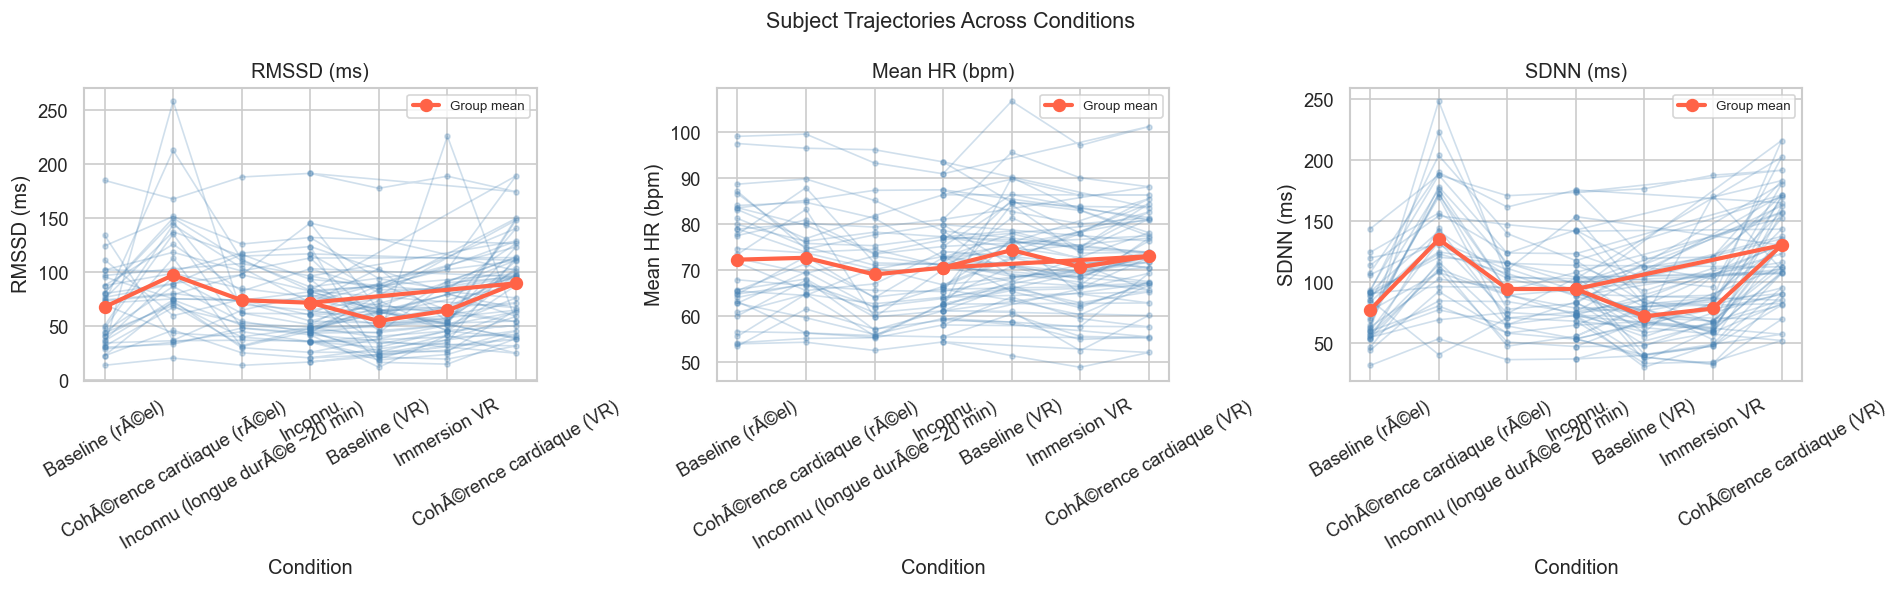

In [ ]:
cond_order_traj = [cond_labels[c] for c in numeric_cols]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, title in zip(
        axes,
        ["rmssd_ms", "hr_mean_bpm", "sdnn_ms"],
        ["RMSSD (ms)", "Mean HR (bpm)", "SDNN (ms)"]):
    pivot = (df.pivot_table(index="subject", columns="condition", values=metric)
               .reindex(columns=cond_order_traj))
    for _, row in pivot.iterrows():
        ax.plot(cond_order_traj, row.values, color="steelblue",
                alpha=0.25, lw=1, marker="o", markersize=3)
    mean_vals = pivot.mean()
    ax.plot(cond_order_traj, mean_vals.values, color="tomato",
            lw=2.5, marker="o", markersize=7, label="Group mean", zorder=5)
    ax.set_title(title)
    ax.set_xlabel("Condition")
    ax.set_ylabel(title)
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)

plt.suptitle("Subject Trajectories Across Conditions", fontsize=13)
plt.tight_layout()
plt.show()

## 17. HRV Metrics Correlation Heatmap

Pearson correlation between HRV metrics across all subjects and conditions. Identifies redundant features and guides feature selection for a classifier (e.g. RMSSD and pNN50 are typically highly correlated).

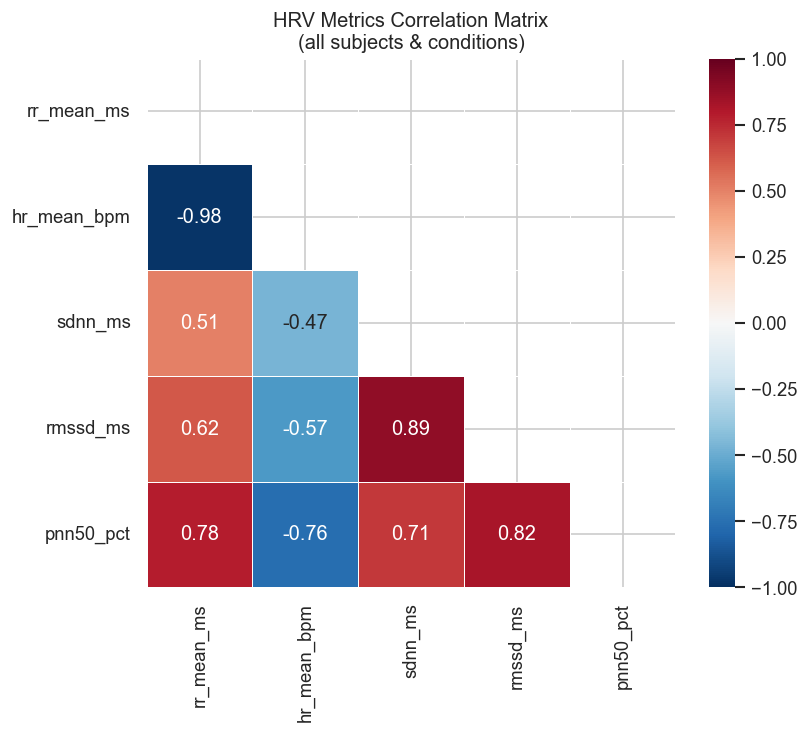

In [ ]:
hrv_cols_corr = ["rr_mean_ms", "hr_mean_bpm", "sdnn_ms", "rmssd_ms", "pnn50_pct"]
corr = df[hrv_cols_corr].corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True, ax=ax)
ax.set_title("HRV Metrics Correlation Matrix\n(all subjects & conditions)", fontsize=12)
plt.tight_layout()
plt.show()